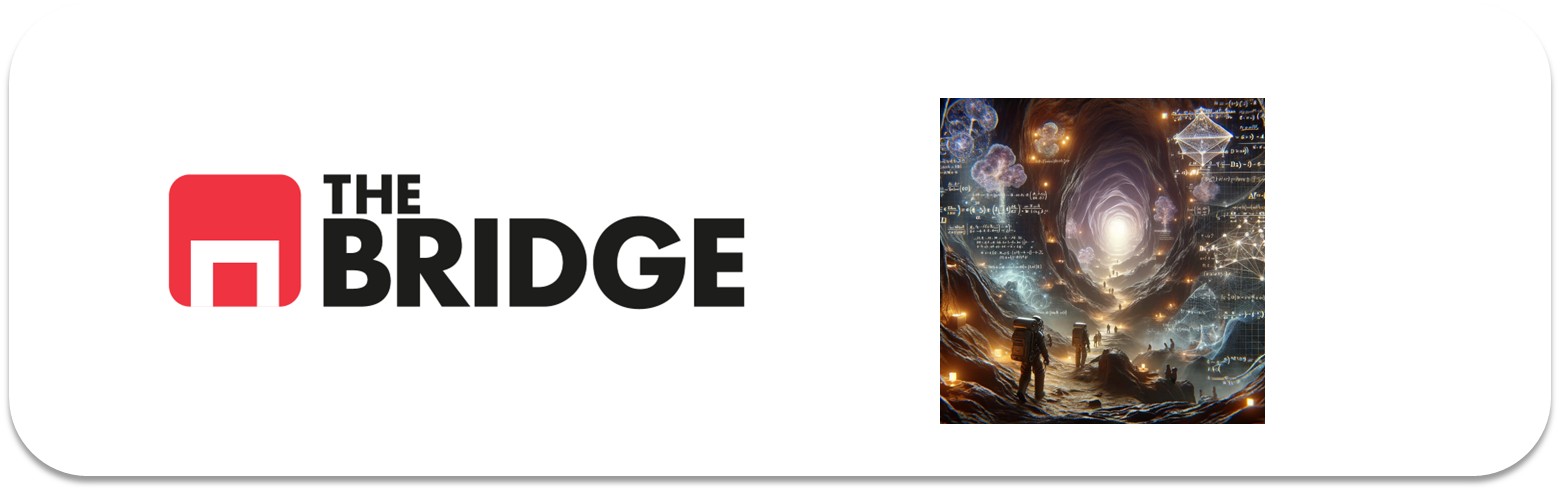

## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [159]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.


In [160]:
df = pd.read_csv("./data/titanic.csv")
df.sample(5)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
382,0,3,male,32.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
822,0,1,male,38.0,0,0,0.0000,S,First,man,True,NaN,Southampton,no,True
457,1,1,female,NaN,1,0,51.8625,S,First,woman,False,D,Southampton,yes,False
183,1,2,male,1.0,2,1,39.0000,S,Second,child,False,F,Southampton,yes,False
312,0,2,female,26.0,1,1,26.0000,S,Second,woman,False,NaN,Southampton,no,False


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [162]:
X = df.iloc[:, 1:] # Otra formas de quitar el target
y = df.iloc[:, 0] # y de quedárselo

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [164]:
y_train.value_counts(True)

survived
0    0.623596
1    0.376404
Name: proportion, dtype: float64

In [165]:
X_train = X_train.drop(columns = ["deck", "embark_town","class","alive"])
X_test = X_test.drop(columns = ["deck", "embark_town","class","alive"])

In [166]:
X_train.embarked.value_counts(dropna=False)

embarked
S      525
C      125
Q       60
NaN      2
Name: count, dtype: int64

In [167]:
print(len(X_train[X_train.age.isna() == False])/len(X_train))

0.8033707865168539


In [168]:
def func_missing_imputer(X, median_col_imputed = [], mode_col_imputed = []):
    X_temp = X.copy()
    
    for col in median_col_imputed:
        valor_imputado = round(X_temp[col].median(),0)
        es_nulo = X_temp[col].isna()
        X_temp.loc[es_nulo,col] = valor_imputado

    for col in mode_col_imputed:
        valor_imputado = X_temp[col].mode().values[0]
        es_nulo = X_temp[col].isna()
        X_temp.loc[es_nulo,col] = valor_imputado
        
    return X_temp
X_train = func_missing_imputer(X_train, median_col_imputed= ["age"], mode_col_imputed= ["embarked"])

In [169]:
X_test = func_missing_imputer(X_test, median_col_imputed= ["age"], mode_col_imputed= ["embarked"])

In [170]:
def func_oneHotEnconder(X, cols_to_encode):
    X_temp = X.copy()
    return pd.get_dummies(X_temp, columns=cols_to_encode, dtype=int)

In [171]:
X_train_encoded = func_oneHotEnconder(X_train, ["sex","embarked","who"])
X_test_encoded = func_oneHotEnconder(X_test, ["sex","embarked","who"])

In [172]:
train_merge = pd.concat([X_train, y_train], axis=1)

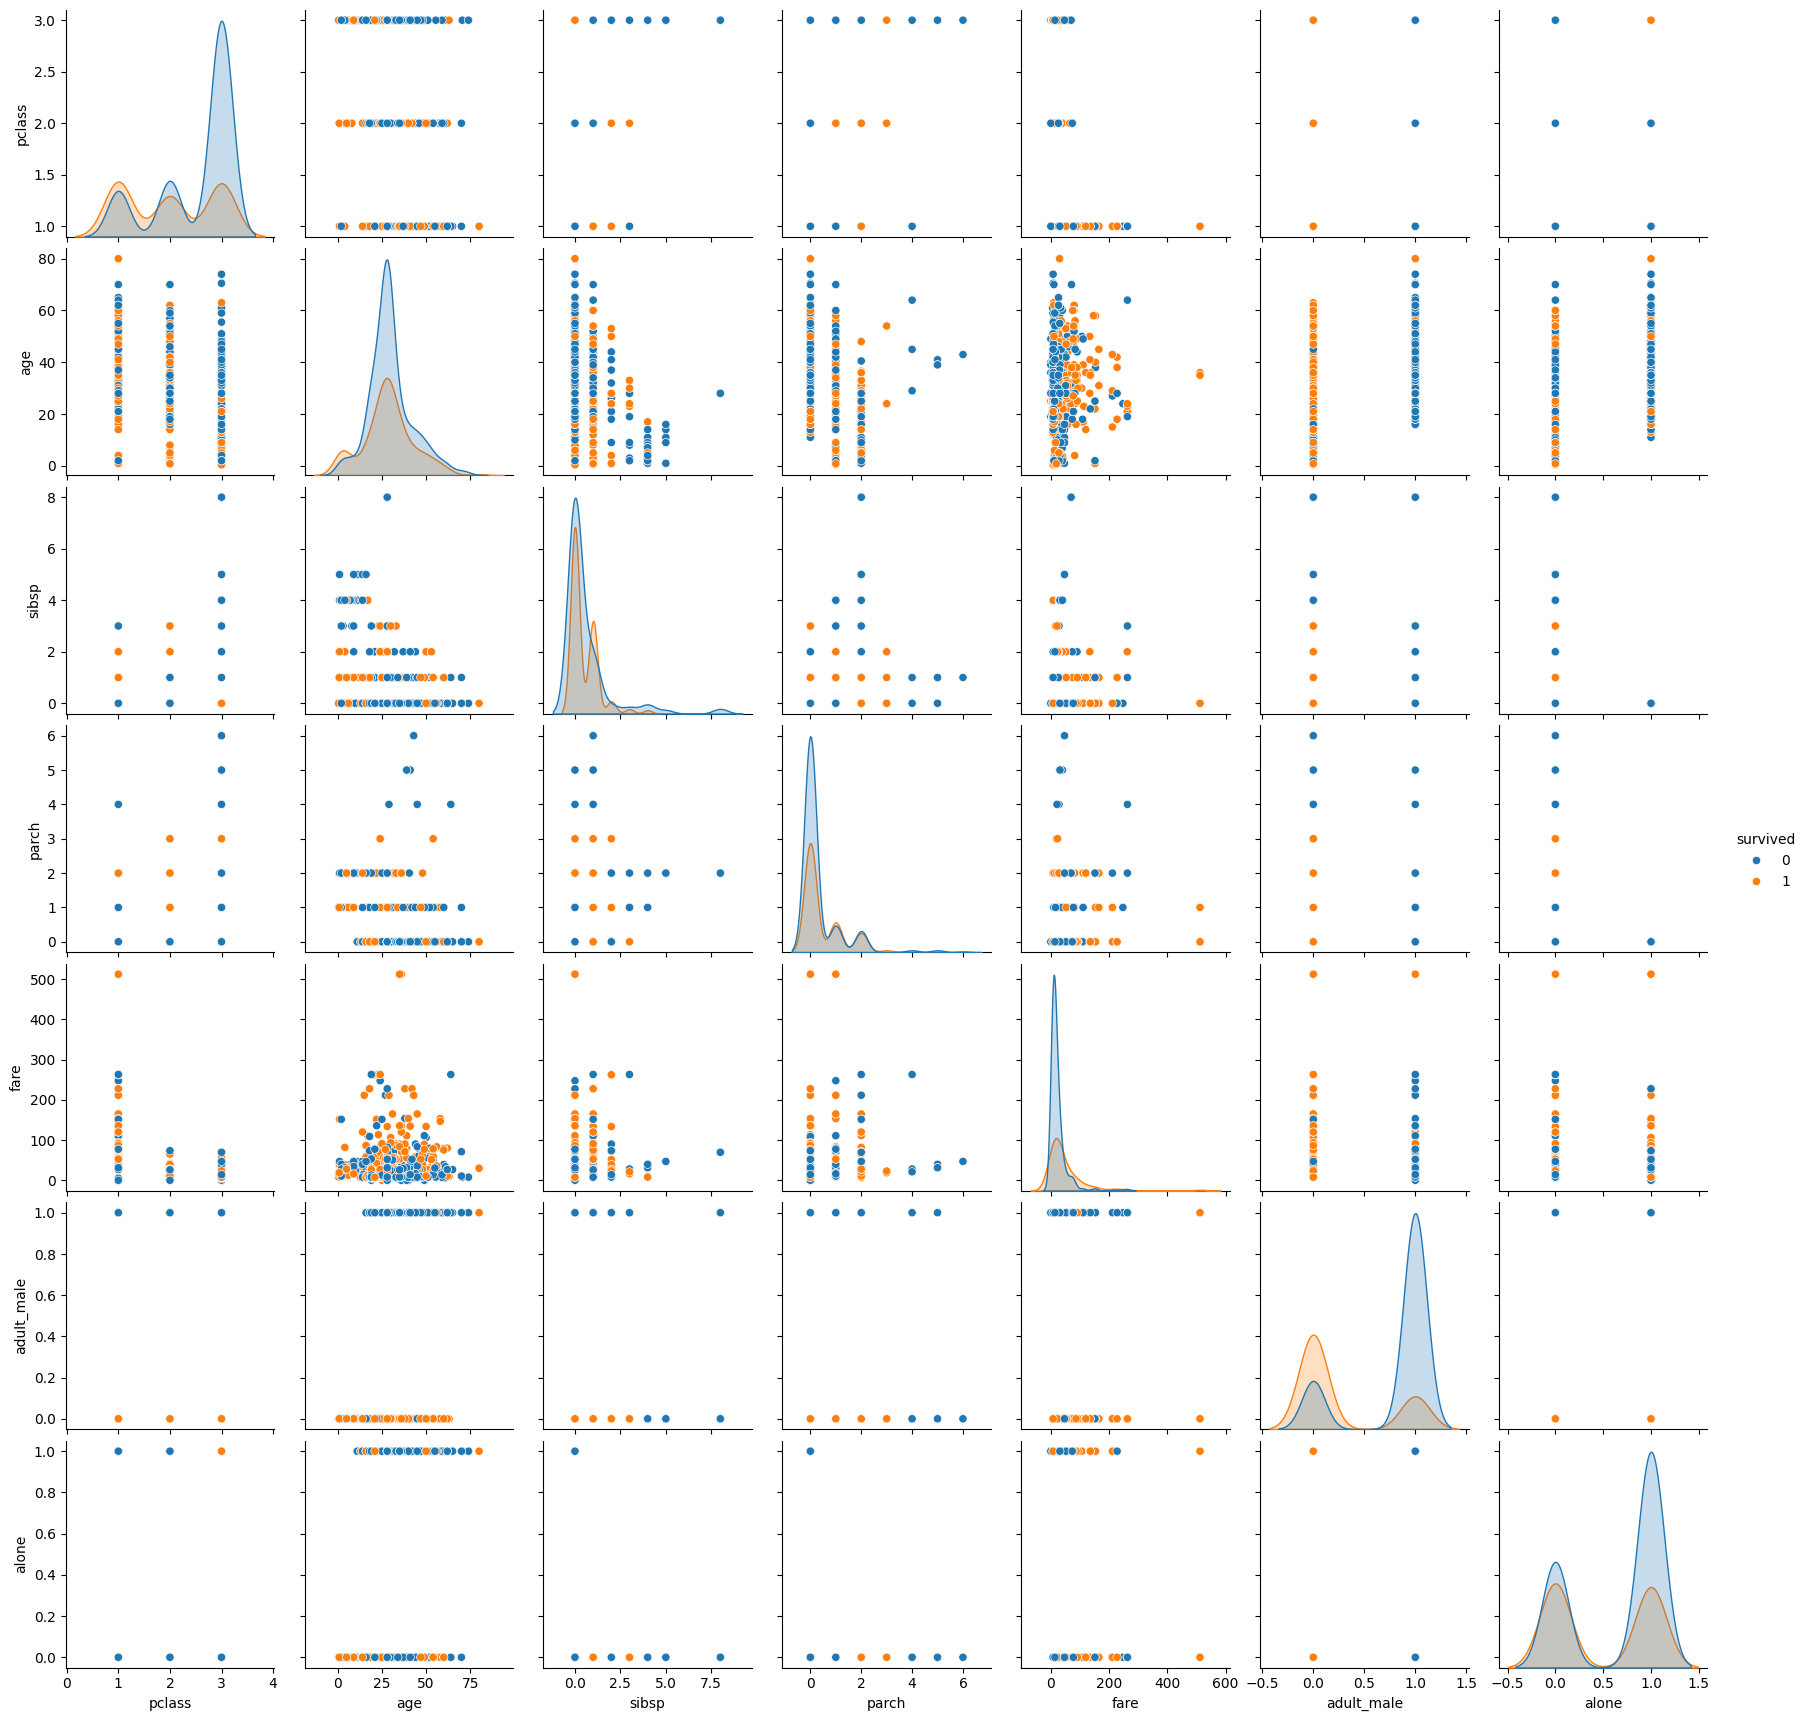

In [173]:
sns.pairplot(train_merge, hue = "survived")

In [174]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      712 non-null    int64  
 1   sex         712 non-null    object 
 2   age         712 non-null    float64
 3   sibsp       712 non-null    int64  
 4   parch       712 non-null    int64  
 5   fare        712 non-null    float64
 6   embarked    712 non-null    object 
 7   who         712 non-null    object 
 8   adult_male  712 non-null    bool   
 9   alone       712 non-null    bool   
dtypes: bool(2), float64(2), int64(3), object(3)
memory usage: 51.5+ KB


In [175]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

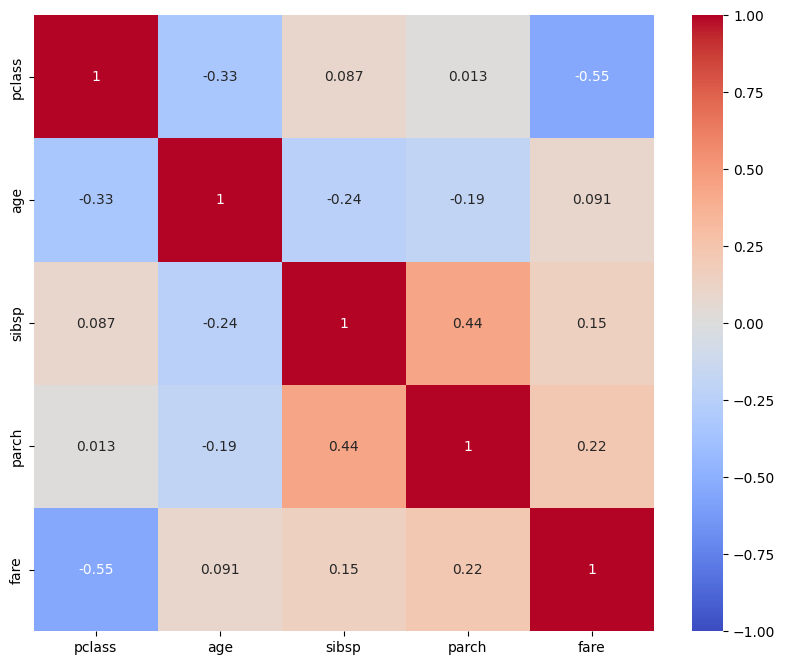

In [154]:
corr_matrix = train_merge[num_cols].corr()

# heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.show()

In [176]:
scaler = StandardScaler()
scaler.fit(X_train_encoded[num_cols])
X_train_scal =scaler.transform(X_train_encoded[num_cols])
X_test_scal =scaler.transform(X_test_encoded[num_cols])

In [ ]:
# modelo Random Forest

param_grid = {
    "n_estimators": [100,200,400],
    "max_depth": [1,5,10,None],
    "min_samples_leaf": [1,10,20,100],
    "class_weight": ["balanced",None],
    "max_features": ['sqrt', 'log2', None]
}

rf_clf = RandomForestClassifier()

rf_grid = GridSearchCV(rf_clf,
                       param_grid= param_grid,
                       cv = 5,
                       scoring= "balanced_accuracy",
                       n_jobs= -1)

rf_grid.fit(X_train_scal,y_train)


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [184]:
print("Mejores hiperparámetros:", rf_grid.best_params_)
print("Mejor score CV:", rf_grid.best_score_)

Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor score CV: 0.6814478971040344


In [188]:
y_pred = rf_grid.best_estimator_.predict(X_test_scal)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.77      0.79       105
           1       0.69      0.73      0.71        74

    accuracy                           0.75       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.75      0.76       179



In [187]:
# Grid de hiperparámetros
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50, 25)],  # topologías: 1 capa y más de 1 capa
    'activation': ['relu', 'tanh'],  # valores posibles: 'identity', 'logistic', 'tanh', 'relu'
    'solver': ['adam', 'sgd'],       # optimizadores
    'alpha': [0.0001, 0.001, 0.01],  # regularización L2
    'learning_rate': ['constant', 'adaptive']  # tasa de aprendizaje
}

# Instancia base
mlp = MLPClassifier(max_iter=500, random_state=42)

mlp_grid = GridSearchCV(
    estimator=mlp,
    param_grid=mlp_param_grid,
    scoring='balanced_accuracy',   # métrica a elegir
    cv=3,                 # validación cruzada
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_scal, y_train)

print("Mejores hiperparámetros MLP:", mlp_grid.best_params_)
print("Mejor score MLP:", mlp_grid.best_score_)


Fitting 3 folds for each of 96 candidates, totalling 288 fits
Mejores hiperparámetros MLP: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50, 25), 'learning_rate': 'adaptive', 'solver': 'sgd'}
Mejor score MLP: 0.669649143525548


In [189]:
y_pred = mlp_grid.best_estimator_.predict(X_test_scal)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.88      0.81       105
           1       0.77      0.58      0.66        74

    accuracy                           0.75       179
   macro avg       0.76      0.73      0.73       179
weighted avg       0.76      0.75      0.75       179



Nos quedamos con Random Forest porque tiene métricas más equilibradas, especialmente el recall de la clase positiva para asegurar que podem predecir mayor número de supervivientes.